In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("Advertising.csv")

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [5]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (200, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [6]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [7]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


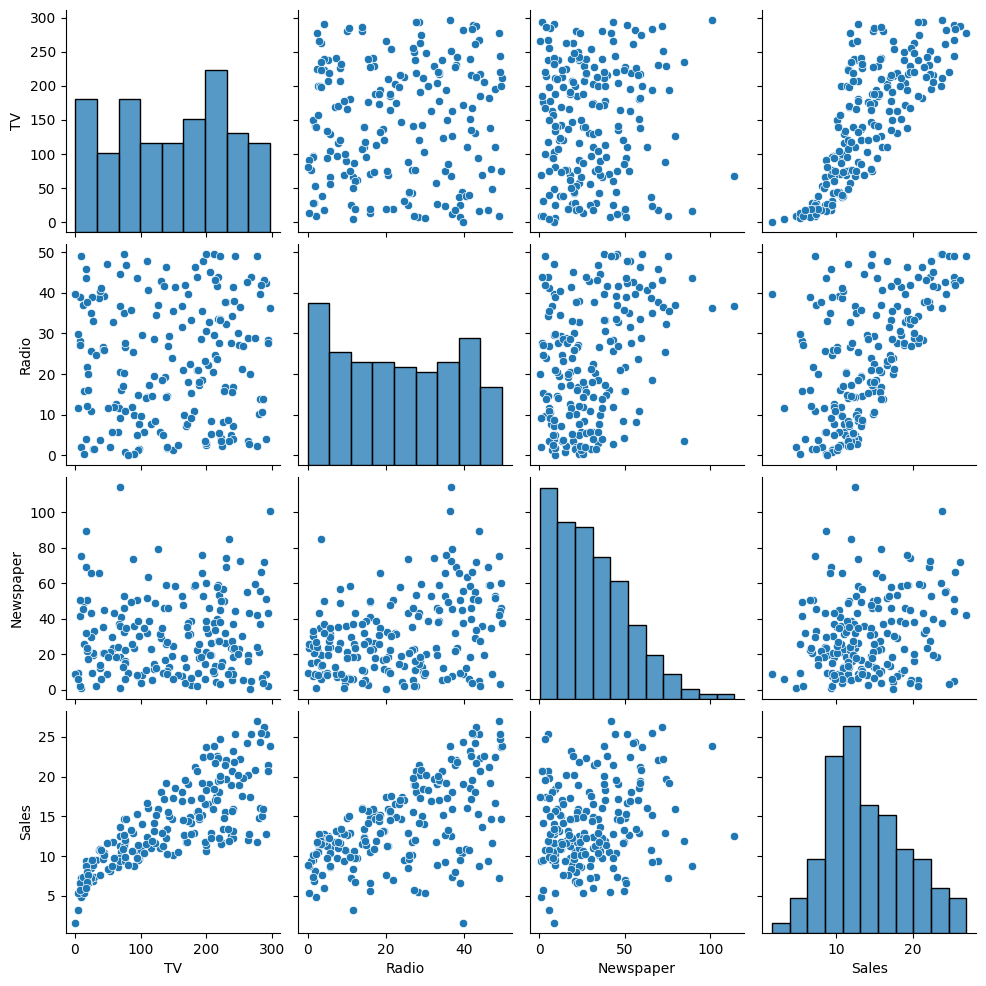

In [8]:
sns.pairplot(df)

plt.show()

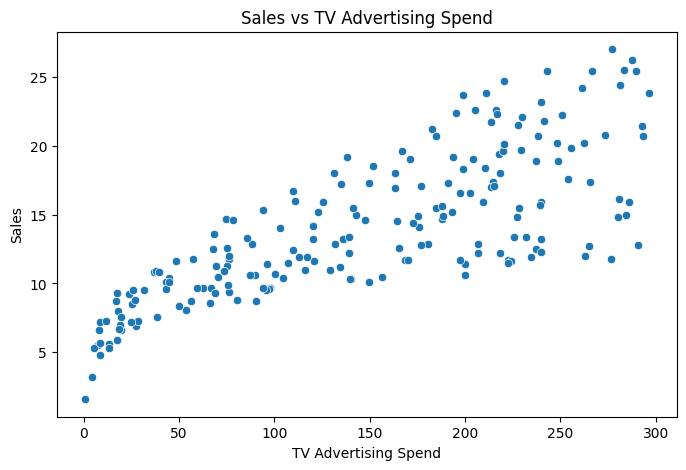

In [9]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="TV",
    y="Sales"
)

plt.title("Sales vs TV Advertising Spend")
plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")

plt.show()

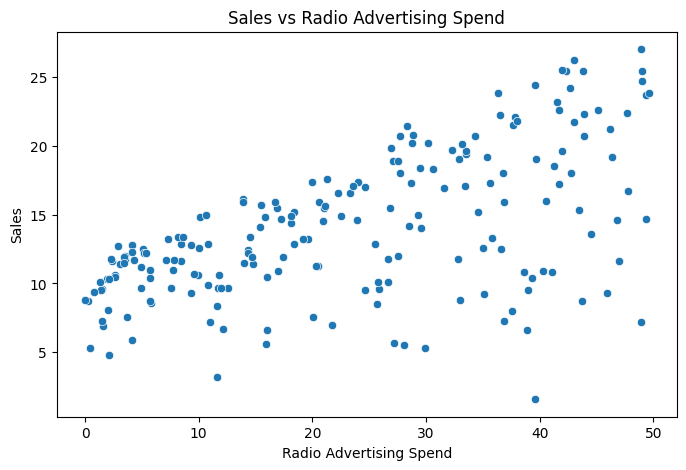

In [10]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Radio",
    y="Sales"
)

plt.title("Sales vs Radio Advertising Spend")
plt.xlabel("Radio Advertising Spend")
plt.ylabel("Sales")

plt.show()

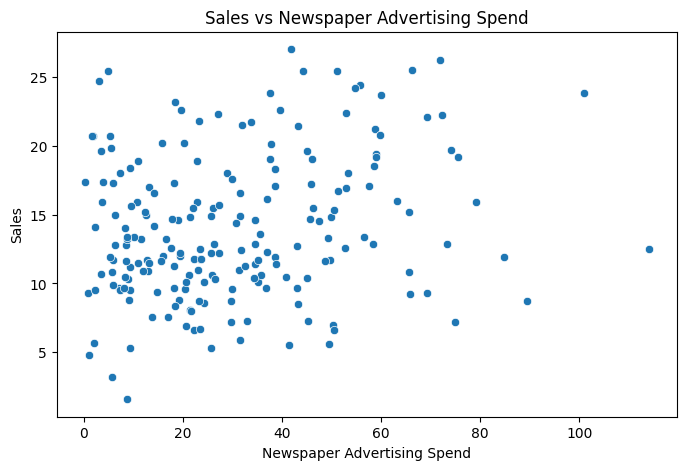

In [11]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Newspaper",
    y="Sales"
)

plt.title("Sales vs Newspaper Advertising Spend")
plt.xlabel("Newspaper Advertising Spend")
plt.ylabel("Sales")

plt.show()

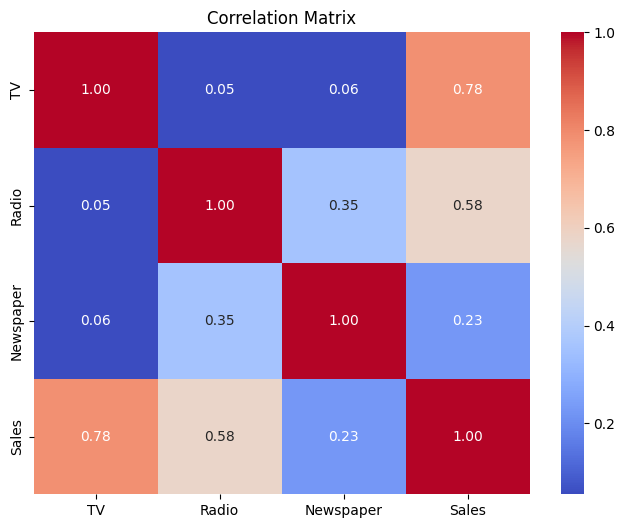

In [12]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [13]:
X = df[["TV", "Radio", "Newspaper"]]

y = df["Sales"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (160, 3)
Testing Data Shape: (40, 3)


In [15]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

LinearRegression()

In [16]:
y_pred_linear = linear_model.predict(X_test)

In [17]:
mae_linear = mean_absolute_error(
    y_test,
    y_pred_linear
)

rmse_linear = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_linear
    )
)

r2_linear = r2_score(
    y_test,
    y_pred_linear
)

print("Linear Regression Results")
print("-------------------------")

print("MAE:", mae_linear)
print("RMSE:", rmse_linear)
print("R² Score:", r2_linear)

Linear Regression Results
-------------------------
MAE: 1.4607567168117603
RMSE: 1.78159966153345
R² Score: 0.899438024100912


In [18]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [19]:
y_pred_rf = rf_model.predict(X_test)

In [20]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("Random Forest Results")
print("---------------------")

print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

Random Forest Results
---------------------
MAE: 0.6200999999999988
RMSE: 0.7685910811348248
R² Score: 0.9812843792541843


In [21]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    
    "MAE": [
        mae_linear,
        mae_rf
    ],
    
    "RMSE": [
        rmse_linear,
        rmse_rf
    ],
    
    "R2 Score": [
        r2_linear,
        r2_rf
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.460757,1.781600,0.899438
1,Random Forest,0.620100,0.768591,0.981284


In [22]:
coefficients = pd.DataFrame({
    "Advertising Channel": X.columns,
    "Coefficient": linear_model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients

,Advertising Channel,Coefficient
1,Radio,0.189195
0,TV,0.044730
2,Newspaper,0.002761


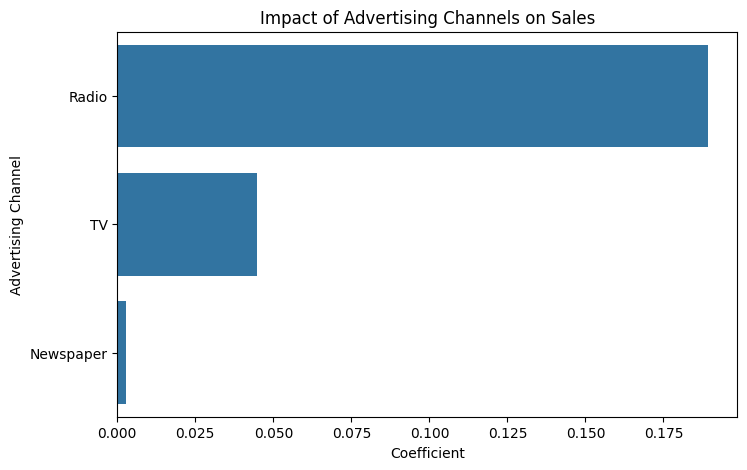

In [23]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Advertising Channel"
)

plt.title("Impact of Advertising Channels on Sales")

plt.show()

In [26]:
feature_importance = pd.DataFrame({
    "Advertising Channel": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Advertising Channel,Importance
0,TV,0.624810
1,Radio,0.362201
2,Newspaper,0.012989


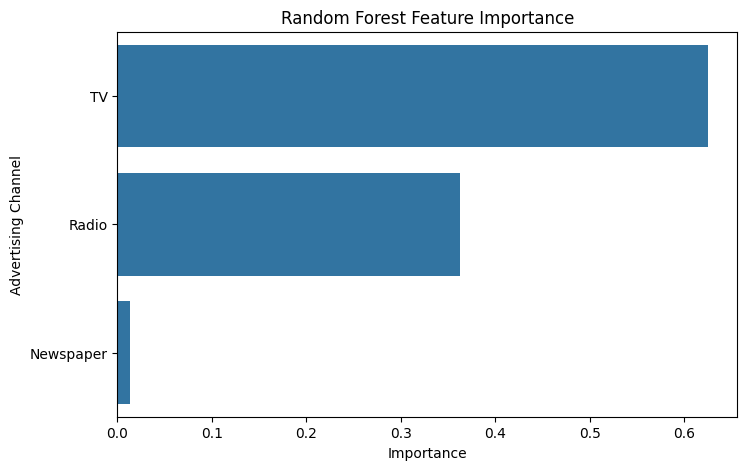

In [27]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Advertising Channel"
)

plt.title("Random Forest Feature Importance")

plt.show()

In [28]:
if r2_linear > r2_rf:
    best_model = linear_model
    best_predictions = y_pred_linear
    best_model_name = "Linear Regression"
else:
    best_model = rf_model
    best_predictions = y_pred_rf
    best_model_name = "Random Forest"

print("Best Model:", best_model_name)

Best Model: Random Forest


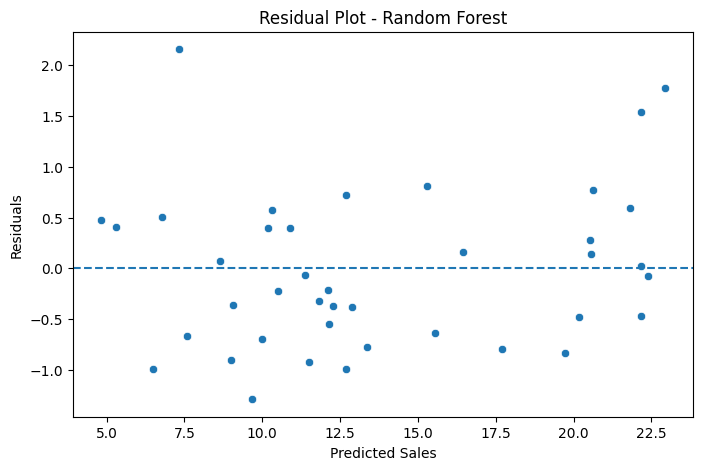

In [29]:
residuals = y_test - best_predictions

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=best_predictions,
    y=residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.title(
    f"Residual Plot - {best_model_name}"
)

plt.show()

In [30]:
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": best_predictions
})

comparison.head(10)

,Actual Sales,Predicted Sales
0,16.9,17.698
1,22.4,21.804
2,21.4,20.628
3,7.3,6.793
4,24.7,22.927
5,12.6,13.379
6,22.3,22.376
7,8.4,9.688
8,11.5,11.826
9,14.9,15.540


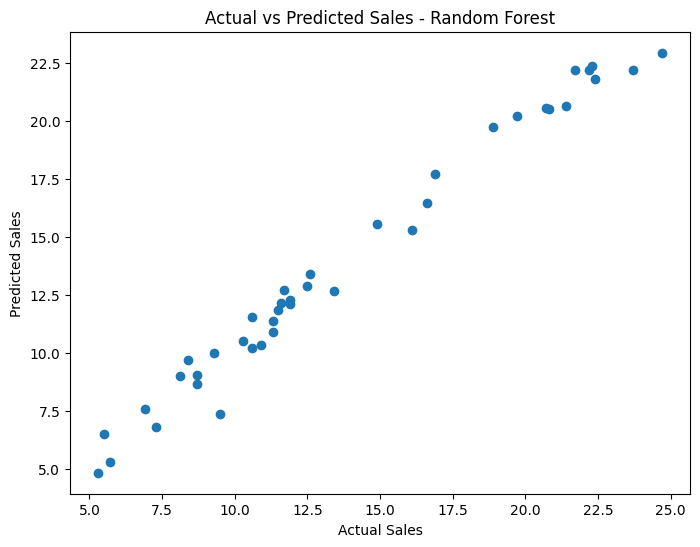

In [31]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title(
    f"Actual vs Predicted Sales - {best_model_name}"
)

plt.show()